<a href="https://colab.research.google.com/github/wardahrana/AI--Customer-Review-Analyzer/blob/main/AI_Customer_Review_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Customer Review Analyzer

This notebook will guide you through building a simple AI-powered customer review analyzer. We will use a pre-trained sentiment analysis model from the Hugging Face `transformers` library to classify reviews as positive, negative, or neutral. We'll start by setting up the environment, then prepare some sample data, perform the analysis, and finally display the results.

### 1. Install Necessary Libraries

First, we need to install the `transformers` library, which provides access to many pre-trained NLP models.

In [1]:
# Install the transformers library
!pip install transformers

### 2. Import Libraries

Next, we'll import `pandas` for data handling and `pipeline` from `transformers` to easily load and use our model.

In [11]:
import pandas as pd
from transformers import pipeline

### 3. Prepare Sample Customer Review Data

For demonstration purposes, let's create a small dataset of customer reviews. In a real scenario, you would load your reviews from a CSV file, a database, or another source.

In [7]:
# Create a list of sample customer reviews
reviews = [
    "This product is amazing! I love its features and design.",
    "The delivery was very slow, and the item arrived damaged.",
    "It's okay, not great, not terrible. Just average.",
    "Best purchase ever! Highly recommend to everyone.",
    "Completely disappointed with the quality. Will not buy again."
]

# Convert the list of reviews into a pandas DataFrame
df = pd.DataFrame({'review_text': reviews})
display(df)

,review_text
0,This product is amazing! I love its features a...
1,"The delivery was very slow, and the item arriv..."
2,"It's okay, not great, not terrible. Just average."
3,Best purchase ever! Highly recommend to everyone.
4,Completely disappointed with the quality. Will...


### 4. Initialize Sentiment Analysis Model

We will use a pre-trained sentiment analysis model. The `pipeline` function makes it easy to load a model and its tokenizer for a specific task like 'sentiment-analysis'.

In [8]:
# Load a pre-trained sentiment analysis model
# This model classifies text into 'POSITIVE', 'NEGATIVE', or 'NEUTRAL'
sentiment_analyzer = pipeline("sentiment-analysis")

print("Sentiment analysis model loaded successfully.")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Sentiment analysis model loaded successfully.


### 5. Perform Sentiment Analysis on Reviews

Now, we'll apply our loaded sentiment analyzer to each review in our DataFrame. The `sentiment_analyzer` function will return a label (e.g., 'POSITIVE', 'NEGATIVE', 'NEUTRAL') and a score for each review.

In [9]:
# Apply the sentiment analysis to each review
# We use .apply() on the 'review_text' column to process each review
results = df['review_text'].apply(lambda x: sentiment_analyzer(x)[0])

# Extract the 'label' and 'score' from the results
df['sentiment'] = results.apply(lambda x: x['label'])
df['sentiment_score'] = results.apply(lambda x: x['score'])

display(df)

,review_text,sentiment,sentiment_score
0,This product is amazing! I love its features a...,POSITIVE,0.999887
1,"The delivery was very slow, and the item arriv...",NEGATIVE,0.999808
2,"It's okay, not great, not terrible. Just average.",POSITIVE,0.989178
3,Best purchase ever! Highly recommend to everyone.,POSITIVE,0.999854
4,Completely disappointed with the quality. Will...,NEGATIVE,0.999758


### 6. Analyze and Summarize Results

Finally, let's look at the distribution of sentiments in our reviews to get an overall idea.


Sentiment Distribution:
sentiment
POSITIVE    3
NEGATIVE    2
Name: count, dtype: int64


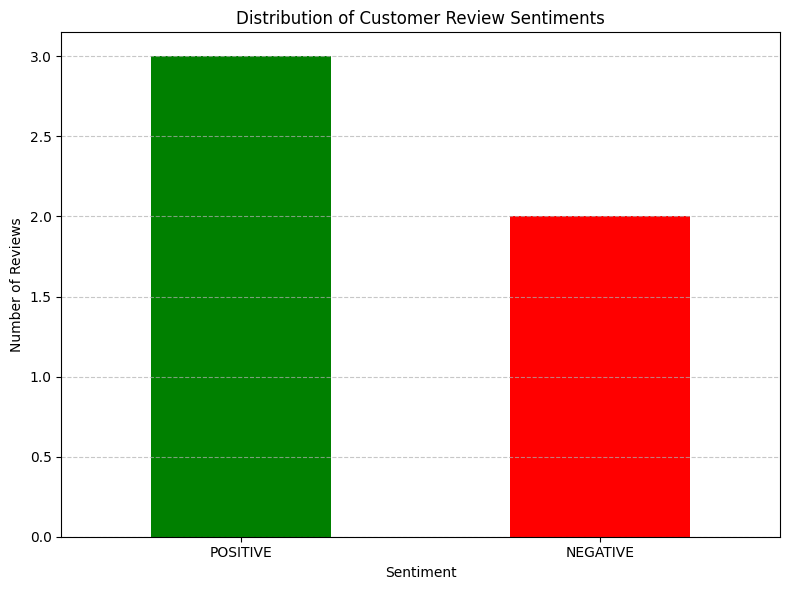

In [10]:
# Get the count of each sentiment category
sentiment_counts = df['sentiment'].value_counts()

print("\nSentiment Distribution:")
print(sentiment_counts)

# You can also visualize this distribution
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Distribution of Customer Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()